<a href="https://colab.research.google.com/github/tusar-verma/Machine-learning-2c2026/blob/feat%2Fnotebook-02/notebook-02/notebooks/notebook_02_titanic-published.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aprendizaje-automatico-dc-uba-ar/material/blob/main/notebooks/notebook_02_titanic-published.ipynb)

# Titanic

En este ejercicio, deberán descargar y explorar el contenido de la base de datos en formato CSV (valores separados por comas) que contiene datos de pasajeros del naufragio del transatlántico Titanic en 1912, incluyendo edad, sexo, clase del pasaje y supervivencia a la tragedia, entre otros.

Completar el notebook de manera de clasificar a los pasajeros en supervivientes y no supervivientes
tan bien como sea posible.

Atención, en este momento de la materia no está permitido usar ninguna técnica de Aprendizaje Automático.
El objetivo es conseguir un buen porcentaje de aciertos sobre estos datos.


## Antes de empezar

Preparamos algunas funciones auxiliares para trabajar:

1. `cargar_datos`: lee el csv con los datos
1. `predict`: dado un conjunto de datos, devuelve la predicción para cada instancia
1. `accuracy`: métrica sobre el desempeño de una predicción definida como:

  $$accuracy = \frac{\#aciertos}{\#predicciones}$$
        
  Su interpretación puede ser:  en cuántos casos acerté.
        

In [1]:
from IPython.display import display
import pandas as pd
from typing import Tuple

def cargar_datos() -> Tuple[pd.DataFrame, pd.Series]:
    """
    Carga los datos del Titanic desde un archivo CSV y devuelve las características (X) y las etiquetas (y).

    Returns:
        X (pd.DataFrame): Características del dataset, excluyendo la columna "Survived" y "PassengerId".
        y (pd.Series): Etiquetas del dataset, correspondientes a la columna "Survived".
    """
    df = pd.read_csv(
        "https://github.com/aprendizaje-automatico-dc-uba-ar/material/raw/main/datasets/data_02/titanic.csv"
    )
    X = df.drop("Survived", axis=1).drop("PassengerId", axis=1)
    y = df.Survived
    return X, y


def predict(X: pd.DataFrame) -> list:
    """
    Predice la salida para cada fila de los datos. Debe definirse primero la función predict_instance para utilizarla
    """
    y_predicted = []
    for x in X.itertuples():
        try:
            y_i = predict_instance(x)
        except NameError:
            raise NameError("Por favor definir la función predict_instance")
        y_predicted.append(y_i)
    return y_predicted


def accuracy(y_predicted: list, y_real: list) -> float:
    """
    Calcula el accuracy entre un y_predicted y un y_real.
    """
    TP_TN = sum([y_i == y_j for (y_i, y_j) in zip(y_predicted, y_real)])
    P_N = len(y_real)
    return TP_TN / P_N

## Ejercicio

Antes de empezar cargamos los datos y los separamos en `X` (dataframe de instancias con atributos que usaremos como columnas y datos como filas), `y` (vector de clases a las que corresponde cada instancia).

Definición de los datos:

Variable|Definición|Interpretación de valores
--------|--------|--------
survival|Sobreviviente|0 = No, 1 = Sí
pclass|Clase de pasaje|1 = 1era, 2 = 2da, 3 = 3era
sex|Sexo|
Age|Edad en años|
sibsp|# hermanos/as/ esposos/as a bordo|
parch|# padres / hijos a bordo|
ticket|Número de Ticket|
fare|Tarifa|
cabin|Número de cabina|
embarked|Puerto de embarque|C = Cherbourg<br>Q = Queenstown<br>S = Southampton


Una recomendación, para este ejercicio y para todos los ejercicios, antes de comenzar el ejercicio explorar los datos para ver qué forma/característica tiene y ganar intuición sobre el dominio en el que se va a trabajar.

Entre muchas cosas, se puede:

  - Inspeccione y verifique el tipo de dato del dataframe. Calcule medidas resumen para las distintas columnas
  - Graficar distintos atributos y observar su distribución (Ej. la edad: ¿son más jóvenes? ¿O más viejos? ¿O un poco y un poco?).
  - Graficar relaciones entre atributos y relaciones entre atributos y la salida (si sobrevivió o no). Ver opciones de `seaborn` sugeridas en el notebook anterior.
  

***Obs.*** Recuerde importar las librerías necesarias como `Matplotlib` o `Seaborn`.


In [2]:
X, y = cargar_datos()

In [3]:
X

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,"Homer, Mr. Harry (""Mr E Haven"")",male,35.0,0,0,111426,26.5500,NaN,C
1,3,"Rintamaki, Mr. Matti",male,35.0,0,0,STON/O 2. 3101273,7.1250,NaN,S
2,2,"Butler, Mr. Reginald Fenton",male,25.0,0,0,234686,13.0000,NaN,S
3,3,"Moutal, Mr. Rahamin Haim",male,NaN,0,0,374746,8.0500,NaN,S
4,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
796,3,"Skoog, Mr. Wilhelm",male,40.0,1,4,347088,27.9000,NaN,S
797,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
798,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
799,1,"Smith, Mr. James Clinch",male,56.0,0,0,17764,30.6958,A7,C


In [4]:
k = pd.DataFrame(y)

In [5]:
(k["Survived"] == 1).sum()

np.int64(315)

In [6]:
X.describe()

,Pclass,Age,SibSp,Parch,Fare
count,801.000000,645.000000,801.000000,801.000000,801.000000
mean,2.295880,30.016543,0.523096,0.395755,33.524848
std,0.846224,14.593394,1.099899,0.827304,51.894603
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,1.000000,21.000000,0.000000,0.000000,7.895800
50%,3.000000,28.500000,0.000000,0.000000,14.458300
75%,3.000000,39.000000,1.000000,0.000000,31.387500
max,3.000000,80.000000,8.000000,6.000000,512.329200


A continuación se encuentra la primera definición de una función que predice. Esta tarea se resuelve devolviendo la etiqueta 0 o 1.

En este punto se puede usar la información disponible del dataframe que considere necesaria, pero para esta primer implementación, la solución planteada es trivial: sobrevivieron todas las personas.



In [8]:
def predict_instance(x: pd.Series) -> int:
    """
    Predice la clase para instancia x.
    """
    prediction = 1  # CAMBIAR ESTA LINEA POR REGLAS

    return prediction

Evaluamos este clasificador:

In [60]:
y_pred = predict(X)
# Completar el algoritmo para mejorar esta performance.

print(f"Accuracy: {round(accuracy(y_pred, y), 3)}")

Accuracy: 0.775


### Consigna

La tarea será escribir un algoritmo para predecir si sobrevivirá o no por instancia que obtenga el mejor valor de Accuracy.

Para hacerlo sólo está permitido utilizar en la predicción reglas que tomen datos de la instancia (sin entrenamiento previo).

Ej: `prediction = x.Sex=="female"`
o combinaciones más complejas con condicionales (if), pero que únicamente utilicen los atributos de la instancia presente (`if x.Sex=="female": prediction = (x.Age % 2 == 0)  else: prediction = 0`.

Como lo que tenemos es un `dataframe` de Pandas, podemos acceder a los atributos también así:
```
if x["Age"] > 10:
    return 1
else:
    ...
```

**No está permitido utilizar otras herramientas/técnicas en este punto.**

¡A armar nuevas funciones de predicción y mejorar el Accuracy!

In [10]:
def predict_instance(x: pd.Series):
    ## COMPLETAR. Modificar las siguientes líneas
    # la variable prediction debe contener la etiqueta 0 o 1
    # este será su algoritmo algoritmo para predecir si sobrevivirá o no por instancia.

    if (x.Sex == "female" or x.Age <= 13):
        prediction = 1
    else:
      prediction = 0

    if (x.Age > 75):
      prediction = 1

    ## FIN DE COMPLETAR
    return prediction



In [39]:
def predict_instance(x: pd.Series):
    # Si la edad es NaN, la tratamos como adulto (e.g., 30 años) para que caiga en la categoría >12.
    age = x.Age if pd.notna(x.Age) else 30
    if (x.Fare > 500) or (x.Sex == "female" or age <= 13):
        prediction = 1
    else:
      prediction = 0


    return prediction

In [ ]:
X[(X.Age < 18)]

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,2,"Mudd, Mr. Thomas Charles",male,16.0,0,0,S.O./P.P. 3,10.5000,NaN,S
9,3,"Van Impe, Miss. Catharina",female,10.0,0,2,345773,24.1500,NaN,S
13,3,"Osen, Mr. Olaf Elon",male,16.0,0,0,7534,9.2167,NaN,S
14,3,"Calic, Mr. Jovo",male,17.0,0,0,315093,8.6625,NaN,S
24,3,"Sunderland, Mr. Victor Francis",male,16.0,0,0,SOTON/OQ 392089,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
715,3,"Goodwin, Master. William Frederick",male,11.0,5,2,CA 2144,46.9000,NaN,S
735,3,"Attalah, Miss. Malake",female,17.0,0,0,2627,14.4583,NaN,C
776,2,"Becker, Master. Richard F",male,1.0,2,1,230136,39.0000,F4,S
790,3,"Eklund, Mr. Hans Linus",male,16.0,0,0,347074,7.7750,NaN,S


In [ ]:
(X["Sex"] == "male").sum()

np.int64(513)

In [ ]:
(X["Sex"] == "female").sum()

np.int64(288)

In [ ]:
(X["Age"] < 13).sum()

np.int64(59)

In [ ]:
(X["Fare"] > 20).sum()

np.int64(343)

In [ ]:
((X["Sex"] == "female") & (X["Age"] > 40)).sum()

np.int64(46)

In [ ]:
(X["Pclass"] == 3).sum()

np.int64(440)

In [41]:
print(X['Age'].isna().sum())

156


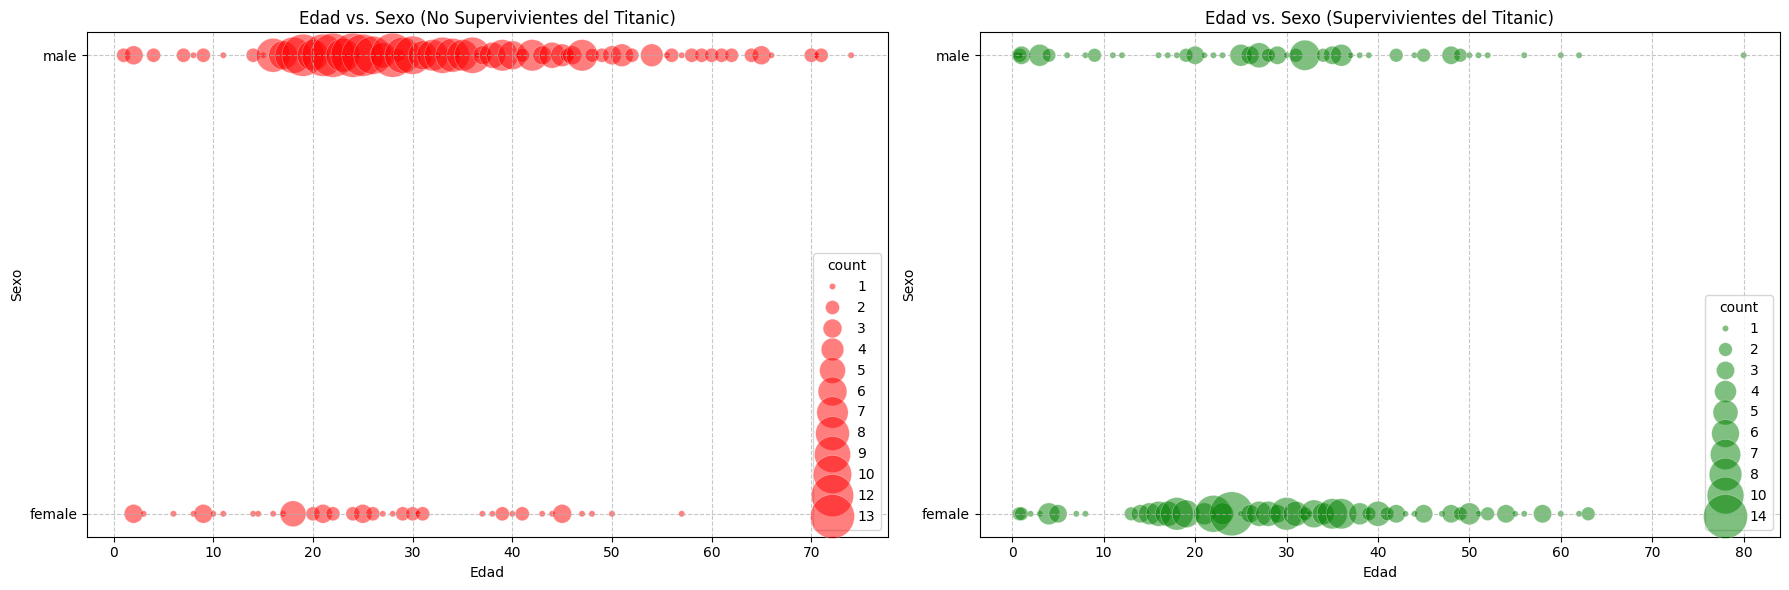

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine X and y into a single DataFrame for plotting
df_plot = pd.concat([X, y], axis=1)

# Drop rows where 'Age' is NaN, as it's required for the plot
df_plot.dropna(subset=['Age'], inplace=True)

# Group by 'Age', 'Sex', and 'Survived' to get counts for point sizing
plot_data = df_plot.groupby(['Age', 'Sex', 'Survived']).size().reset_index(name='count')

# Map 'Survived' to colors and titles
status_map = {
    0: {'color': 'red', 'title': 'No Supervivientes'},
    1: {'color': 'green', 'title': 'Supervivientes'}
}

# Create a single figure with two subplots side-by-side
# Adjust figsize for smaller plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot for Non-Survivors (index 0)
current_plot_data_non_survivors = plot_data[plot_data['Survived'] == 0]
sns.scatterplot(
    data=current_plot_data_non_survivors,
    x='Age',
    y='Sex',
    size='count',
    sizes=(20, 1000),  # Adjust point size range as needed
    alpha=0.5,
    color=status_map[0]['color'],
    legend='full',
    ax=axes[0] # Plot on the first subplot
)
axes[0].set_title(f'Edad vs. Sexo ({status_map[0]['title']} del Titanic)')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Sexo')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot for Survivors (index 1)
current_plot_data_survivors = plot_data[plot_data['Survived'] == 1]
sns.scatterplot(
    data=current_plot_data_survivors,
    x='Age',
    y='Sex',
    size='count',
    sizes=(20, 1000),  # Adjust point size range as needed
    alpha=0.5,
    color=status_map[1]['color'],
    legend='full',
    ax=axes[1] # Plot on the second subplot
)
axes[1].set_title(f'Edad vs. Sexo ({status_map[1]['title']} del Titanic)')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Sexo')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

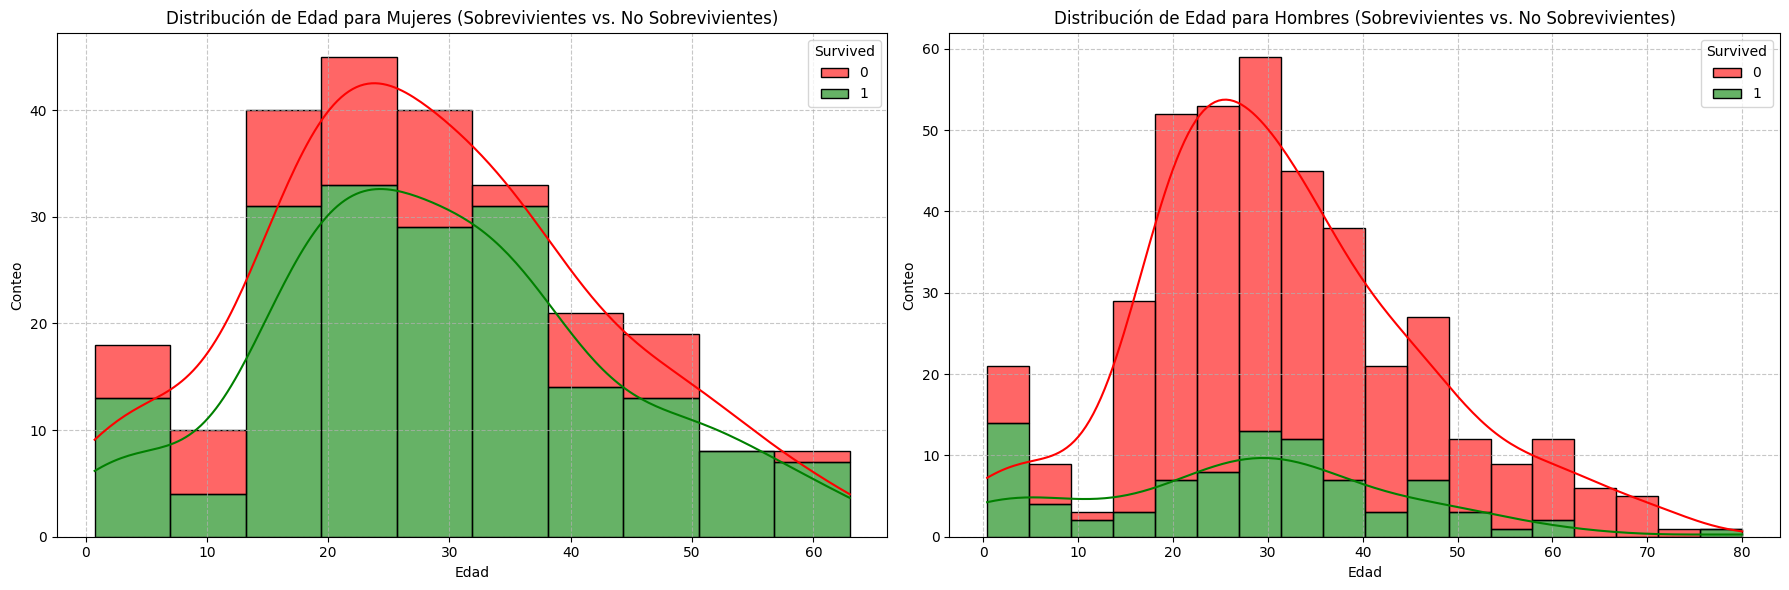

In [24]:
df_plot = pd.concat([X, y], axis=1)

# Drop rows where 'Age' is NaN, as it's required for the plot
df_plot.dropna(subset=['Age'], inplace=True)

# Define colors for survivors (1: green) and non-survivors (0: red)
palette_colors = {1: 'green', 0: 'red'}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Histogram for Females
women_data = df_plot[df_plot['Sex'] == 'female']
sns.histplot(
    data=women_data,
    x='Age',
    hue='Survived',
    multiple='stack',
    palette=palette_colors,
    alpha=0.6, # Transparency
    kde=True, # Optional: add Kernel Density Estimate
    ax=axes[0]
)
axes[0].set_title('Distribución de Edad para Mujeres (Sobrevivientes vs. No Sobrevivientes)')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Conteo')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Histogram for Males
men_data = df_plot[df_plot['Sex'] == 'male']
sns.histplot(
    data=men_data,
    x='Age',
    hue='Survived',
    multiple='stack',
    palette=palette_colors,
    alpha=0.6, # Transparency
    kde=True, # Optional: add Kernel Density Estimate
    ax=axes[1]
)
axes[1].set_title('Distribución de Edad para Hombres (Sobrevivientes vs. No Sobrevivientes)')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Conteo')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

<Figure size 1400x700 with 0 Axes>

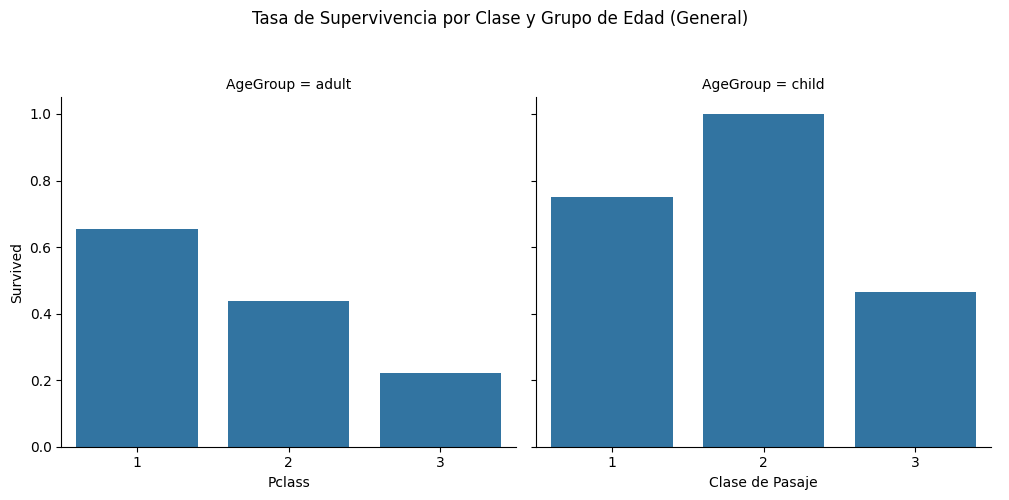

<Figure size 1400x700 with 0 Axes>

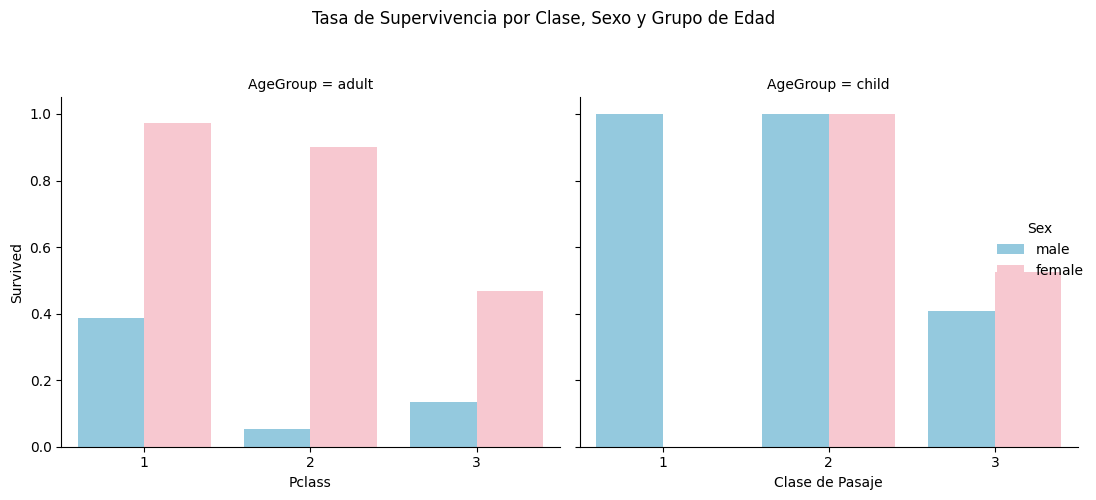

In [57]:
# Ensure df_plot is available and up-to-date
df_plot = pd.concat([X, y], axis=1)

# Create an 'AgeGroup' column for better visualization
df_plot['AgeGroup'] = df_plot['Age'].apply(lambda x: 'child' if x <= 13 else 'adult')

# Fill NaN Age values for plotting, perhaps with a median or a separate category,
# but for this plot, let's just drop them if age is central to the grouping.
df_plot_filtered = df_plot.dropna(subset=['Age'])

# Plot 1: Survival Rate by Pclass and AgeGroup (without Sex separation)
plt.figure(figsize=(14, 7))
sns.catplot(
    data=df_plot_filtered,
    x='Pclass',
    y='Survived',
    col='AgeGroup', # Separate columns for children and adults
    kind='bar',
    errorbar=None # Remove error bars for clarity in this context
)
plt.suptitle('Tasa de Supervivencia por Clase y Grupo de Edad (General)', y=1.02)
plt.ylabel('Tasa de Supervivencia Promedio')
plt.xlabel('Clase de Pasaje')
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

# Plot 2: Survival Rate by Pclass, Sex and AgeGroup (with Sex separation)
plt.figure(figsize=(14, 7))
sns.catplot(
    data=df_plot_filtered,
    x='Pclass',
    y='Survived',
    hue='Sex',
    col='AgeGroup', # Separate columns for children and adults
    kind='bar',
    palette={'male': 'skyblue', 'female': 'pink'},
    errorbar=None # Remove error bars for clarity in this context
)
plt.suptitle('Tasa de Supervivencia por Clase, Sexo y Grupo de Edad', y=1.02)
plt.ylabel('Tasa de Supervivencia Promedio')
plt.xlabel('Clase de Pasaje')
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()


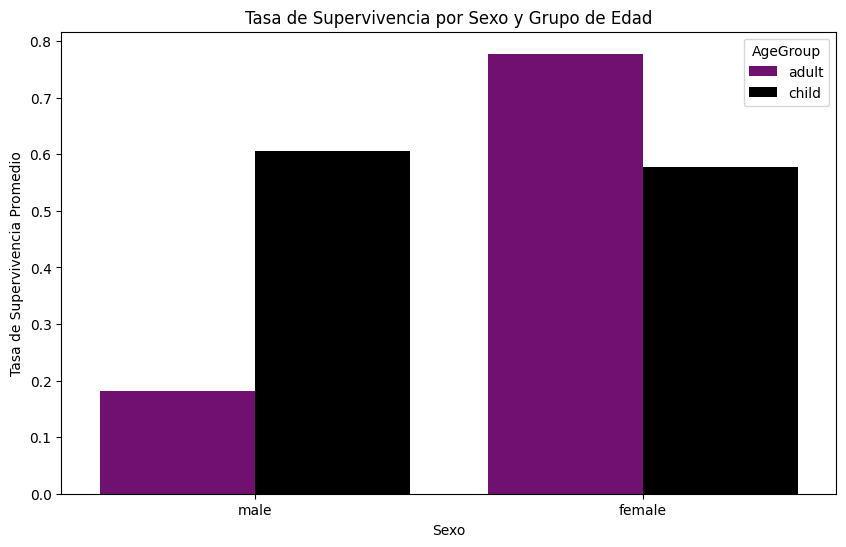

In [56]:

# Existing barplot for Sex and AgeGroup
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_plot_filtered,
    x='Sex',
    y='Survived',
    hue='AgeGroup',
    palette={'child': 'black', 'adult': 'purple'},
    errorbar=None
)
plt.title('Tasa de Supervivencia por Sexo y Grupo de Edad')
plt.ylabel('Tasa de Supervivencia Promedio')
plt.xlabel('Sexo')
plt.show()

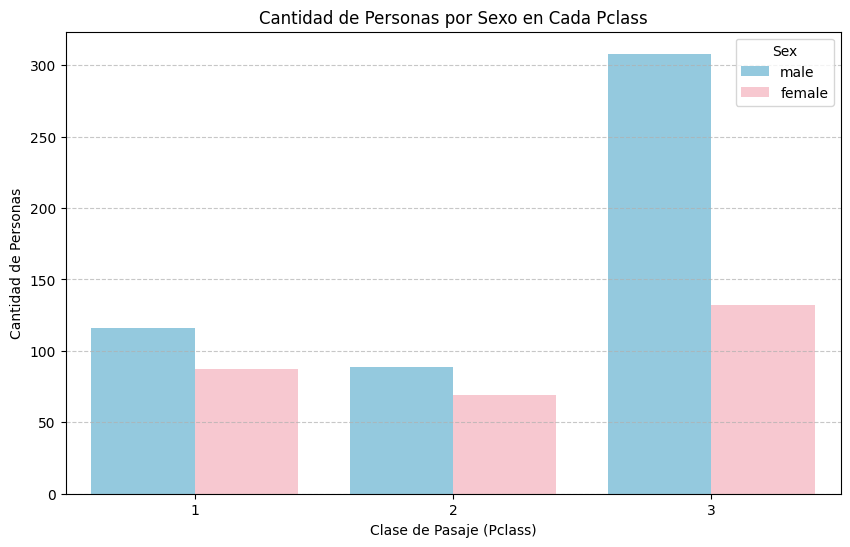

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df_plot is available and up-to-date
df_plot = pd.concat([X, y], axis=1)

# Create a figure with a single subplot
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_plot,
    x='Pclass',
    hue='Sex',
    palette={'male': 'skyblue', 'female': 'pink'},
)
plt.title('Cantidad de Personas por Sexo en Cada Pclass')
plt.xlabel('Clase de Pasaje (Pclass)')
plt.ylabel('Cantidad de Personas')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [59]:
def predict_instance(x: pd.Series):
    prediction = 0

    if (x.Age <= 13 and x.Pclass == 2):
        prediction = 1

    if (x.Age <= 13 and x.Pclass == 1 and x.Sex == "male"):
        prediction = 1

    if (x.Age > 13 and x.Sex == "female"):
      prediction = 1

    return prediction


<Figure size 1400x700 with 0 Axes>

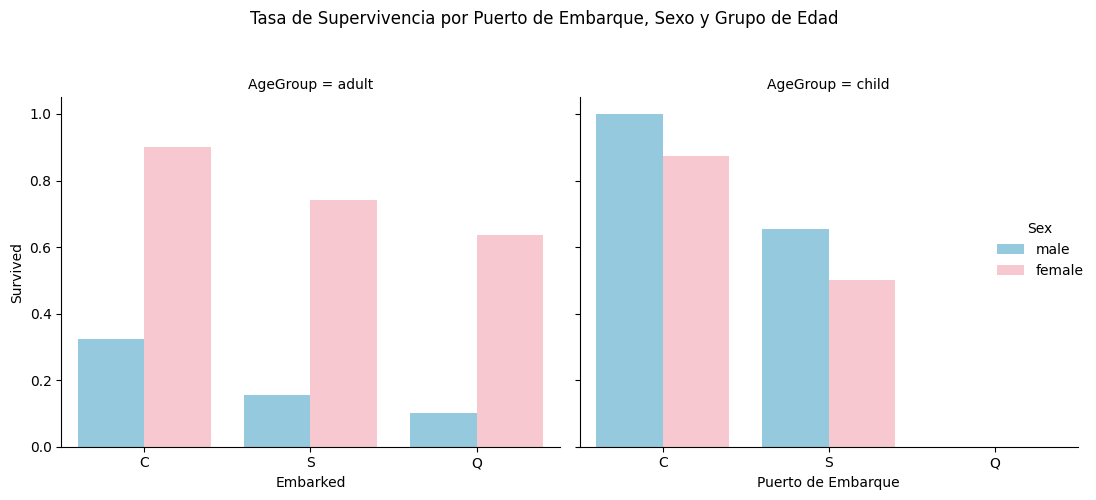

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df_plot is available and up-to-date
df_plot = pd.concat([X, y], axis=1)

# Create an 'AgeGroup' column for better visualization
df_plot['AgeGroup'] = df_plot['Age'].apply(lambda x: 'child' if x <= 13 else 'adult')

# Drop rows where 'Age' or 'Embarked' is NaN, as they are central to the grouping
df_plot_filtered = df_plot.dropna(subset=['Age', 'Embarked'])

plt.figure(figsize=(14, 7))
sns.catplot(
    data=df_plot_filtered,
    x='Embarked',
    y='Survived',
    hue='Sex',
    col='AgeGroup', # Separate columns for children and adults
    kind='bar',
    palette={'male': 'skyblue', 'female': 'pink'},
    errorbar=None # Remove error bars for clarity in this context
)
plt.suptitle('Tasa de Supervivencia por Puerto de Embarque, Sexo y Grupo de Edad', y=1.02)
plt.ylabel('Tasa de Supervivencia Promedio')
plt.xlabel('Puerto de Embarque')
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

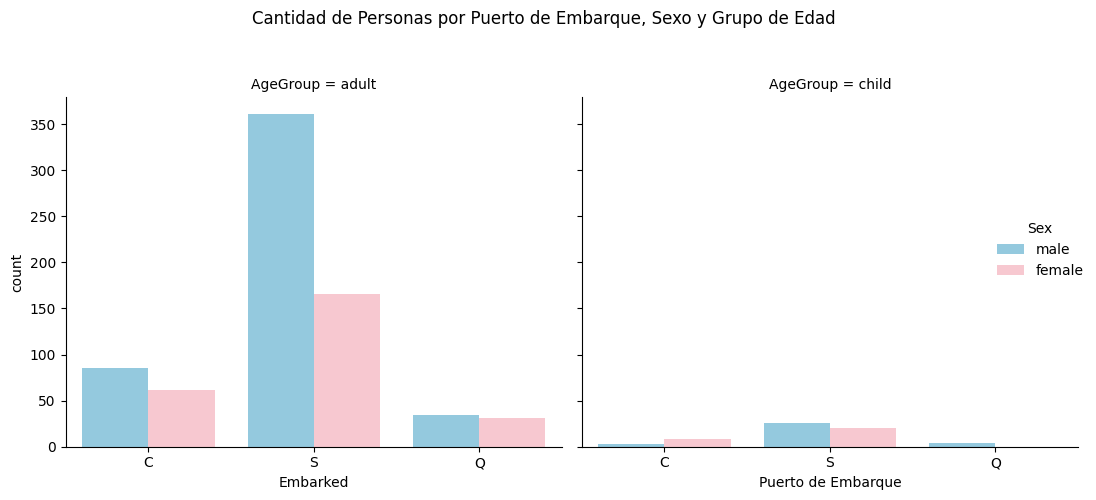

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df_plot is available and up-to-date
df_plot = pd.concat([X, y], axis=1)

# Create an 'AgeGroup' column if it doesn't exist (or re-create to ensure consistency)
df_plot['AgeGroup'] = df_plot['Age'].apply(lambda x: 'child' if x <= 13 else 'adult')

# Drop rows where 'Embarked' is NaN, as it's central to the grouping
df_plot_filtered = df_plot.dropna(subset=['Embarked'])

# Create the countplot
sns.catplot(
    data=df_plot_filtered,
    x='Embarked',
    hue='Sex',
    col='AgeGroup', # Separate columns for children and adults
    kind='count', # Specify countplot
    palette={'male': 'skyblue', 'female': 'pink'}
)
plt.suptitle('Cantidad de Personas por Puerto de Embarque, Sexo y Grupo de Edad', y=1.02)
plt.ylabel('Cantidad de Personas')
plt.xlabel('Puerto de Embarque')
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

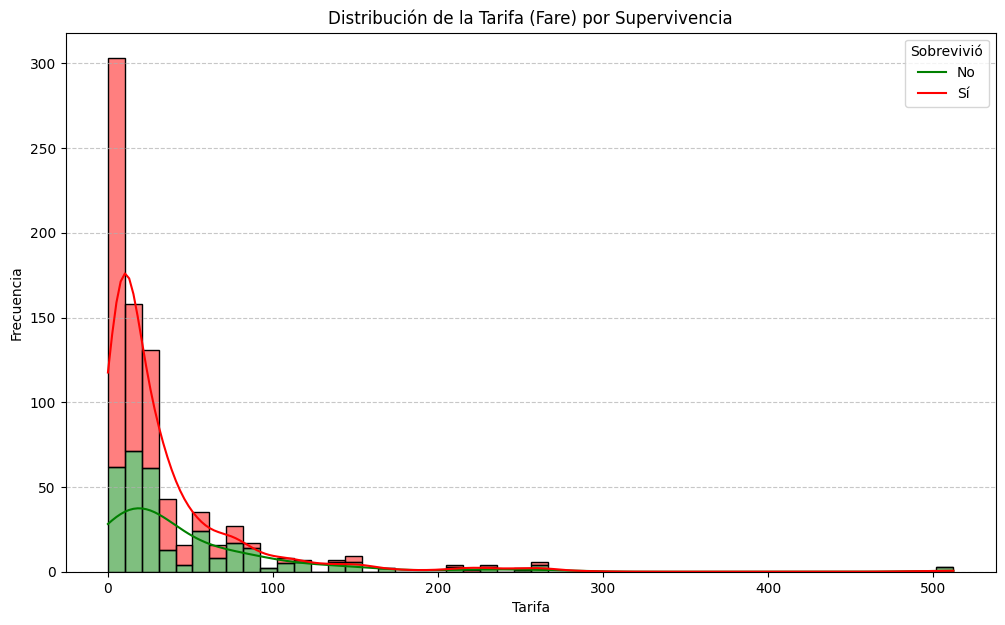

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df_plot is available and up-to-date
df_plot = pd.concat([X, y], axis=1)

# Create the histogram for 'Fare' distribution, separated by 'Survived' status
plt.figure(figsize=(12, 7))
sns.histplot(
    data=df_plot,
    x='Fare',
    hue='Survived',
    bins=50, # Adjust the number of bins as needed for better visualization
    kde=True, # Add a Kernel Density Estimate to show the shape of the distribution
    palette={0: 'red', 1: 'green'}, # Use distinct colors for survived and not survived
    multiple='stack' # Stack the bars for better comparison, or 'dodge' for side-by-side
)
plt.title('Distribución de la Tarifa (Fare) por Supervivencia')
plt.xlabel('Tarifa')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Sobrevivió', labels=['No', 'Sí'])
plt.show()